Importing dependencies, loading data and best configurations chosen from feature selection

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Load config
with open("models/best_config.json") as f:
    cfg = json.load(f)

# Load data
train_df = pd.read_csv("Dataset/train.csv")
test_df  = pd.read_csv("Dataset/test.csv")

train_df[cfg["input_field"]] = train_df[cfg["input_field"]].fillna("")
test_df[cfg["input_field"]]  = test_df[cfg["input_field"]].fillna("")

y_train = train_df["label"].values
y_test  = test_df["label"].values

print("Config:", json.dumps(cfg, indent=2))
print(f"\nTrain: {len(train_df)} | Test: {len(test_df)}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")


Config: {
  "feature_type": "tfidf",
  "input_field": "cleaned_text",
  "ngram_range": [
    1,
    2
  ],
  "best_C": 10.0,
  "max_features": 50000,
  "vector_size": 100
}

Train: 33043 | Test: 11015
Device: cpu


Building feature matrix from vectorizer

In [2]:
# Load the saved vectorizer from Notebook 2
vectorizer = joblib.load("models/best_vectorizer.pkl")

# Transform using the already-fitted vectorizer (no re-fitting)
X_train = vectorizer.transform(train_df[cfg["input_field"]])
X_test  = vectorizer.transform(test_df[cfg["input_field"]])

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"Feature type : sparse matrix (TF-IDF)")


X_train shape: (33043, 50000)
X_test shape : (11015, 50000)
Feature type : sparse matrix (TF-IDF)


TF-IDF vectorizer scanned every article in the training set and built a vocabulary of 50,000 most common words/phrases. This vocabulary is fixed and these 50,000 most common words are tracked if they exist in each article. If a word exists, the vector score is updated for the corresponding matrix index that represents the word in the vocabulary. So each sample has this 50,000 vocabulary score. Most of the vector scores for a single data sample are zero because each article contains fewer than 50,000 words/phrases.

Below is the vocabulary score of the top 10 features from the vectorizer for the first sample (index = 0)

In [14]:
row = X_train[0].toarray().flatten()
print("Top 10 features for the first training example:")
top_indices = np.argsort(row)[-10:][::-1]
feature_names = vectorizer.get_feature_names_out()
for idx in top_indices:
    print(f"{feature_names[idx]}: {row[idx]:.4f}")

Top 10 features for the first training example:
author: 0.2762
letter: 0.2203
signed letter: 0.2065
writer: 0.1946
unequivocally: 0.1360
forceful: 0.1335
name: 0.1274
conscience: 0.1151
dictatorship: 0.1145
signed: 0.1119


Next, we start with the model trainig. We first train a Logistic regresssion.

Training Logistic Regression...

Logistic Regression Results:
  accuracy    : 0.9953
  precision   : 0.9953
  recall      : 0.9949
  f1          : 0.9951
  roc_auc     : 0.9996


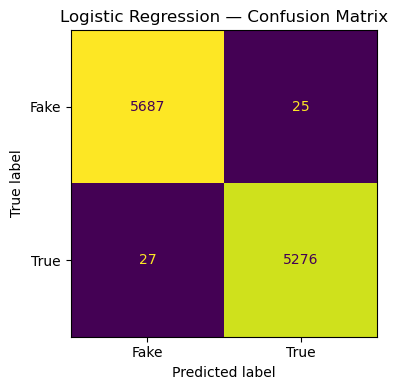

In [15]:
print("Training Logistic Regression...")
lr = LogisticRegression(C=cfg["best_C"], max_iter=1000, solver="lbfgs", n_jobs=-1)
lr.fit(X_train, y_train)

lr_preds  = lr.predict(X_test)
lr_proba  = lr.predict_proba(X_test)[:, 1]

lr_metrics = {
    "accuracy" : accuracy_score(y_test, lr_preds),
    "precision": precision_score(y_test, lr_preds),
    "recall"   : recall_score(y_test, lr_preds),
    "f1"       : f1_score(y_test, lr_preds),
    "roc_auc"  : roc_auc_score(y_test, lr_proba)
}

print("\nLogistic Regression Results:")
for k, v in lr_metrics.items():
    print(f"  {k:<12}: {v:.4f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, lr_preds,
    display_labels=["Fake", "True"], ax=ax, colorbar=False)
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()


Next we train our SVM

Reducing dimensions with TruncatedSVD (LSA)...
Reduced shape: (33043, 300)

Training SVM (RBF kernel)... this may take a few minutes

SVM (RBF) Results:
  accuracy    : 0.9928
  precision   : 0.9913
  recall      : 0.9938
  f1          : 0.9926
  roc_auc     : 0.9993


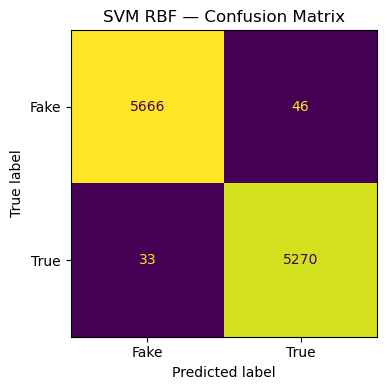

In [16]:
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer

print("Reducing dimensions with TruncatedSVD (LSA)...")
svd = TruncatedSVD(n_components=300, random_state=42)
normalizer = Normalizer(norm="l2")

X_train_svd = normalizer.fit_transform(svd.fit_transform(X_train))
X_test_svd  = normalizer.transform(svd.transform(X_test))

print(f"Reduced shape: {X_train_svd.shape}")
print("\nTraining SVM (RBF kernel)... this may take a few minutes")

svm = SVC(kernel="rbf", C=cfg["best_C"], probability=True, random_state=42)
svm.fit(X_train_svd, y_train)

svm_preds = svm.predict(X_test_svd)
svm_proba = svm.predict_proba(X_test_svd)[:, 1]

svm_metrics = {
    "accuracy" : accuracy_score(y_test, svm_preds),
    "precision": precision_score(y_test, svm_preds),
    "recall"   : recall_score(y_test, svm_preds),
    "f1"       : f1_score(y_test, svm_preds),
    "roc_auc"  : roc_auc_score(y_test, svm_proba)
}

print("\nSVM (RBF) Results:")
for k, v in svm_metrics.items():
    print(f"  {k:<12}: {v:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, svm_preds,
    display_labels=["Fake", "True"], ax=ax, colorbar=False)
ax.set_title("SVM RBF — Confusion Matrix")
plt.tight_layout()
plt.show()


Next we move to test a Neural Network model (PyTorch MLP)

Training MLP...
  Epoch  5/20 — loss: 0.0249
  Epoch 10/20 — loss: 0.0089
  Epoch 15/20 — loss: 0.0057
  Epoch 20/20 — loss: 0.0054

MLP Results:
  accuracy    : 0.9918
  precision   : 0.9913
  recall      : 0.9917
  f1          : 0.9915
  roc_auc     : 0.9990


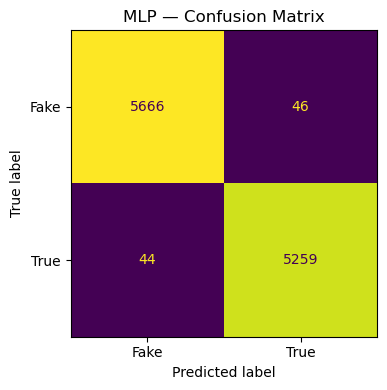

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reuse SVD-reduced features from Cell 4 for memory efficiency
X_train_t = torch.tensor(X_train_svd, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_svd,  dtype=torch.float32)
y_train_t = torch.tensor(y_train,     dtype=torch.float32)
y_test_t  = torch.tensor(y_test,      dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=64, shuffle=True)

# MLP architecture
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

model     = MLP(input_dim=X_train_svd.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

# Training loop
print("Training MLP...")
for epoch in range(20):
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:>2}/20 — loss: {epoch_loss/len(train_loader):.4f}")

# Evaluation
model.eval()
with torch.no_grad():
    mlp_proba = model(X_test_t.to(device)).cpu().numpy()
mlp_preds = (mlp_proba >= 0.5).astype(int)

mlp_metrics = {
    "accuracy" : accuracy_score(y_test, mlp_preds),
    "precision": precision_score(y_test, mlp_preds),
    "recall"   : recall_score(y_test, mlp_preds),
    "f1"       : f1_score(y_test, mlp_preds),
    "roc_auc"  : roc_auc_score(y_test, mlp_proba)
}

print("\nMLP Results:")
for k, v in mlp_metrics.items():
    print(f"  {k:<12}: {v:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, mlp_preds,
    display_labels=["Fake", "True"], ax=ax, colorbar=False)
ax.set_title("MLP — Confusion Matrix")
plt.tight_layout()
plt.show()


Model Comparison

=== Model Comparison ===
                     accuracy  precision  recall      f1  roc_auc
Logistic Regression    0.9953     0.9953  0.9949  0.9951   0.9996
SVM (RBF)              0.9928     0.9913  0.9938  0.9926   0.9993
MLP                    0.9918     0.9913  0.9917  0.9915   0.9990


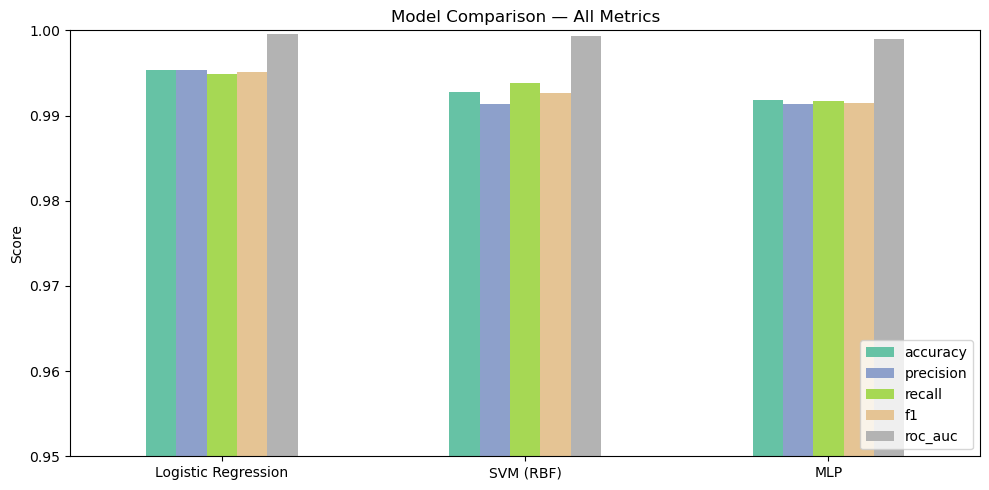

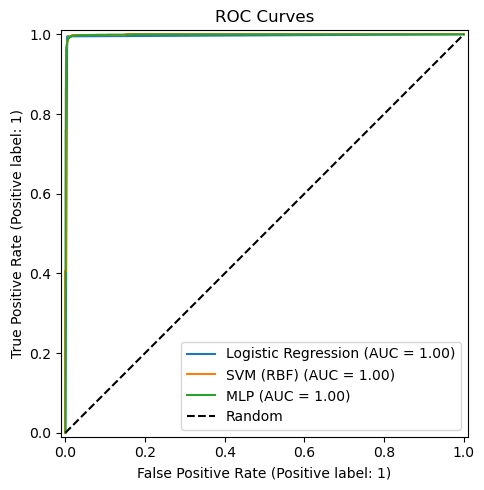

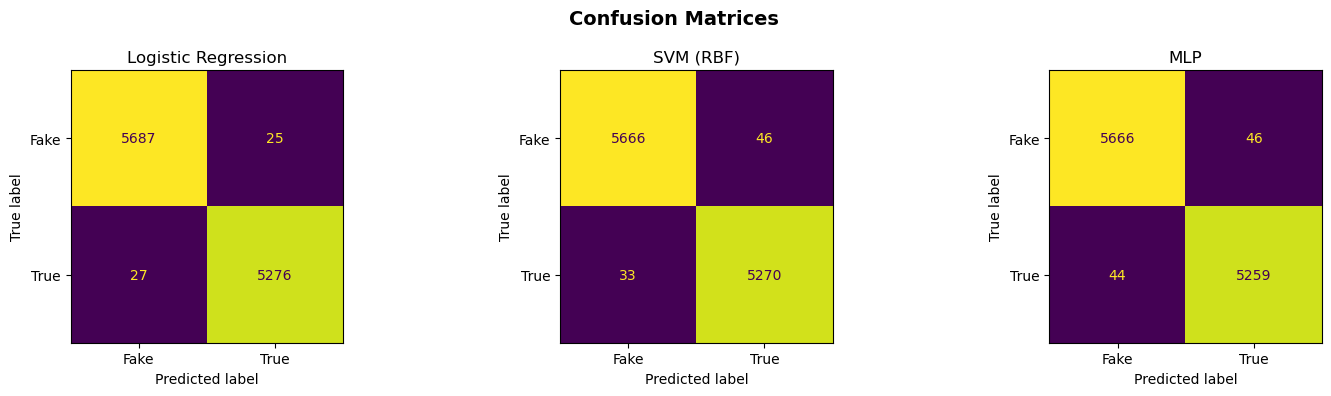

In [18]:
# Compile all metrics into one table
all_metrics = {
    "Logistic Regression": lr_metrics,
    "SVM (RBF)"          : svm_metrics,
    "MLP"                : mlp_metrics,
}

comp_df = pd.DataFrame(all_metrics).T.round(4)
print("=== Model Comparison ===")
print(comp_df.to_string())

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
comp_df.plot(kind="bar", ax=ax, ylim=(0.95, 1.0), rot=0, colormap="Set2")
ax.set_title("Model Comparison — All Metrics")
ax.set_ylabel("Score")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ROC curves — all three on one plot
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, lr_preds,  name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, svm_proba, name="SVM (RBF)",           ax=ax)
RocCurveDisplay.from_predictions(y_test, mlp_proba, name="MLP",                 ax=ax)
ax.set_title("ROC Curves")
ax.plot([0,1],[0,1],"k--", label="Random")
ax.legend()
plt.tight_layout()
plt.show()

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, preds) in zip(axes, [
    ("Logistic Regression", lr_preds),
    ("SVM (RBF)",           svm_preds),
    ("MLP",                 mlp_preds)
]):
    ConfusionMatrixDisplay.from_predictions(y_test, preds,
        display_labels=["Fake","True"], ax=ax, colorbar=False)
    ax.set_title(name)
plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


Save the best model

In [20]:
import os

os.makedirs("models", exist_ok=True)

# Automatically pick best model by F1
best_name = comp_df["f1"].idxmax()
print(f"Best model by F1: {best_name} ({comp_df.loc[best_name, 'f1']:.4f})")

if best_name == "Logistic Regression":
    joblib.dump(lr, "models/best_model.pkl")
    meta = {"model_type": "logistic_regression", "file": "models/best_model.pkl"}

elif best_name == "SVM (RBF)":
    joblib.dump(svm, "models/best_model.pkl")
    joblib.dump(svd, "models/best_svd.pkl")
    joblib.dump(normalizer, "models/best_normalizer.pkl")
    meta = {"model_type": "svm_rbf", "file": "models/best_model.pkl",
            "svd": "models/best_svd.pkl", "normalizer": "models/best_normalizer.pkl"}

elif best_name == "MLP":
    torch.save(model.state_dict(), "models/best_model.pt")
    meta = {"model_type": "mlp", "file": "models/best_model.pt",
            "input_dim": X_train_svd.shape[1],
            "svd": "models/best_svd.pkl", "normalizer": "models/best_normalizer.pkl"}
    joblib.dump(svd, "models/best_svd.pkl")
    joblib.dump(normalizer, "models/best_normalizer.pkl")

# Save model metadata
meta["best_f1"] = comp_df.loc[best_name, "f1"]
with open("models/best_model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved artifacts:")
for k, v in meta.items():
    print(f"  {k}: {v}")


Best model by F1: Logistic Regression (0.9951)
Saved artifacts:
  model_type: logistic_regression
  file: models/best_model.pkl
  best_f1: 0.9951


Summary

In [21]:
with open("models/best_model_meta.json") as f:
    meta = json.load(f)

print("=" * 55)
print("     NOTEBOOK 3 — MODEL TRAINING SUMMARY")
print("=" * 55)
print(f"""
FEATURE REPRESENTATION
----------------------
  Type       : TF-IDF (from Notebook 2)
  Input      : cleaned_text (body-only)
  Ngram range: (1, 2)
  Vocab size : 50,000
  For SVM/MLP: TruncatedSVD → 300 dims + L2 norm

MODELS TRAINED
--------------
  1. Logistic Regression  (C={cfg['best_C']}, solver=lbfgs)
  2. SVM                  (kernel=RBF, C={cfg['best_C']})
  3. MLP                  (256→128→1, ReLU, Dropout=0.3, 20 epochs)

RESULTS
-------""")

for model_name, row in comp_df.iterrows():
    marker = " ← BEST" if model_name == best_name else ""
    print(f"  {model_name:<22} "
          f"Acc: {row['accuracy']:.4f}  "
          f"F1: {row['f1']:.4f}  "
          f"AUC: {row['roc_auc']:.4f}{marker}")

print(f"""
SAVED ARTIFACTS
---------------
  models/best_vectorizer.pkl
  models/best_config.json
  models/best_model_meta.json
  {meta['file']}
""")
print("=" * 55)


     NOTEBOOK 3 — MODEL TRAINING SUMMARY

FEATURE REPRESENTATION
----------------------
  Type       : TF-IDF (from Notebook 2)
  Input      : cleaned_text (body-only)
  Ngram range: (1, 2)
  Vocab size : 50,000
  For SVM/MLP: TruncatedSVD → 300 dims + L2 norm

MODELS TRAINED
--------------
  1. Logistic Regression  (C=10.0, solver=lbfgs)
  2. SVM                  (kernel=RBF, C=10.0)
  3. MLP                  (256→128→1, ReLU, Dropout=0.3, 20 epochs)

RESULTS
-------
  Logistic Regression    Acc: 0.9953  F1: 0.9951  AUC: 0.9996 ← BEST
  SVM (RBF)              Acc: 0.9928  F1: 0.9926  AUC: 0.9993
  MLP                    Acc: 0.9918  F1: 0.9915  AUC: 0.9990

SAVED ARTIFACTS
---------------
  models/best_vectorizer.pkl
  models/best_config.json
  models/best_model_meta.json
  models/best_model.pkl

